In [1]:
import json
import os

os.environ["SPS_HOME"] = "/Users/z5114326/Documents/GitHub/python-fsps/src/fsps/libfsps"

import fsps
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [5]:
dat_dir = "../data/"
ref_band = "v"

# Restart kernel and run first section for both band_types

In [ ]:
band_type = "SDSS"  # JC is vega, SDSS is AB

In [3]:
bands_path = os.path.join(dat_dir, "supplementary/bands.json")
with open(bands_path, "r") as f:
    bands_dict = json.load(f)

mw_path = os.path.join(dat_dir, "mw/gcs/mw_gcs.csv")
mw_gcs = pd.read_csv(mw_path)

bands = list(bands_dict[band_type].keys())
bands_fsps = [bands_dict[band_type][band]["fsps"] for band in bands]

assert (band_type == "JC") | (band_type == "SDSS"), "band_type must be JC or SDSS"

if band_type == "JC":
    compute_vega_mags = True
elif band_type == "SDSS":
    compute_vega_mags = False

sp = fsps.StellarPopulation(imf_type=2, zcontinuous=1, compute_vega_mags=compute_vega_mags)
sp.params["add_dust_emission"] = False
sp.params["dust1"] = 0
sp.params["dust2"] = 0
sp.params["fcstar"] = 0.0
sp.params["add_neb_continuum"] = False
sp.params["add_neb_emission"] = False
sp.params["add_agb_dust_model"] = False
sp.params["agb_dust"] = 0.0
sp.params["tpagb_norm_type"] = 0

feh_lst = np.linspace(0, -2.5, 5)
# age_lst = np.linspace(6, 14, 10)
age_lst = np.linspace(10, 14, 10)


for feh in feh_lst:
    feh_name = str(feh)
    feh_name = feh_name.replace("-", "n").replace(".", "_")
    ref_path = os.path.join(dat_dir, "mw/color_testing/", feh_name + ".csv")

    if not os.path.exists(ref_path):
        # create new DataFrame (define columns if needed)
        df = pd.DataFrame()
    else:
        # load existing CSV
        df = pd.read_csv(ref_path)

    df_dict = {}
    for band in bands_fsps:
        df_dict[band] = []
        for age in age_lst:
            mag = sp.get_mags(tage=age, bands=[band])[0]
            df_dict[band].append(mag)

    for band in df_dict.keys():
        df[band] = df_dict[band]

    df.to_csv(ref_path, index=False)

# Run after to plot colours

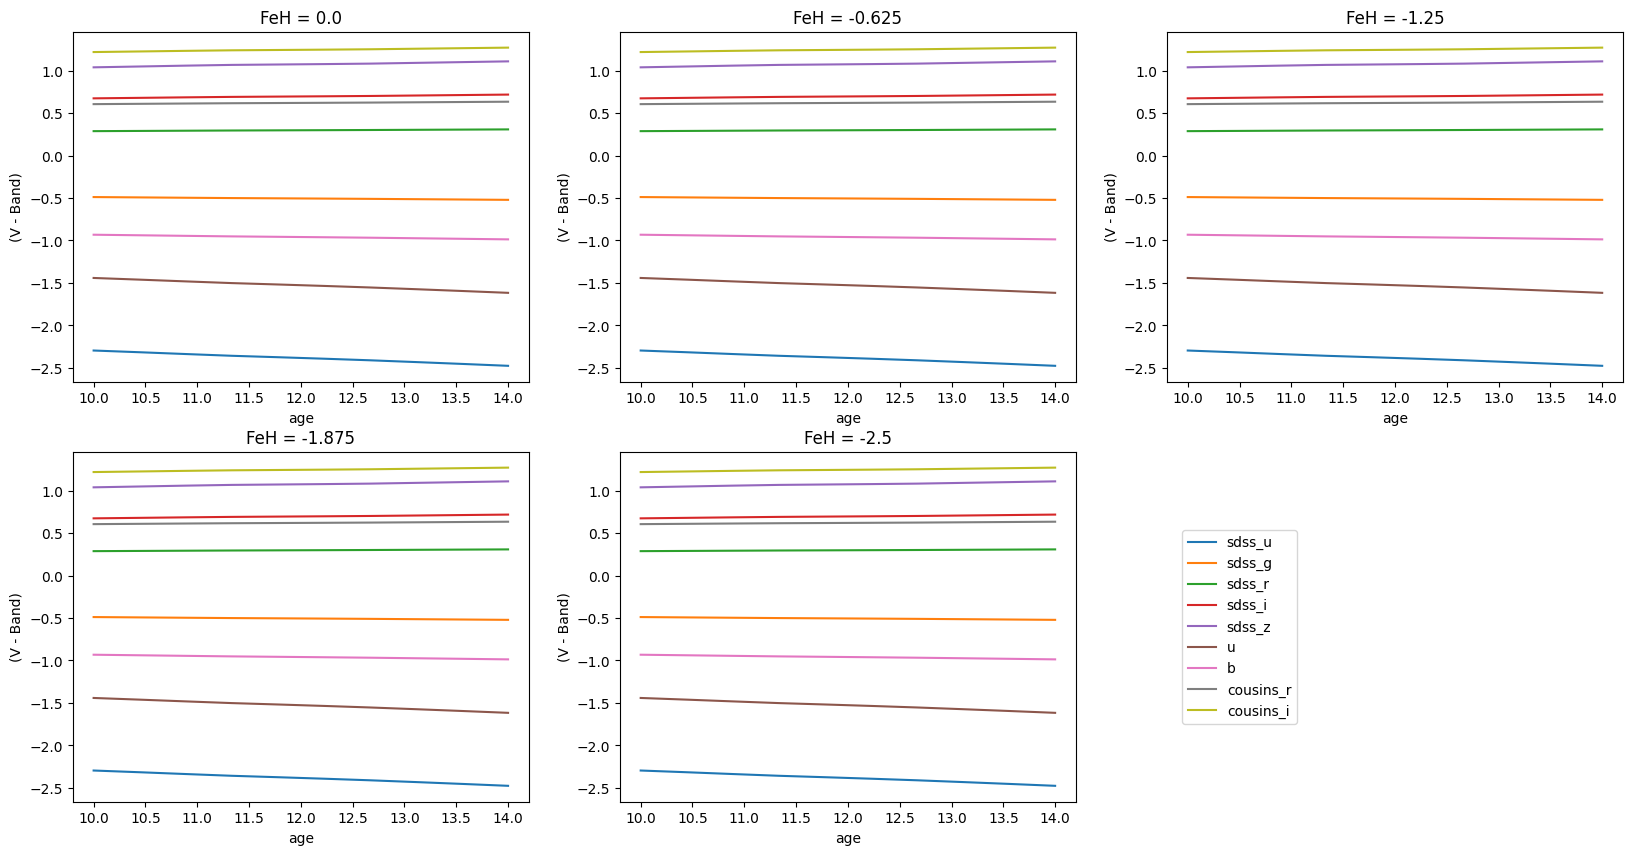

In [6]:
feh_lst = np.linspace(0, -2.5, 5)
# age_lst = np.linspace(6, 14, 10)
age_lst = np.linspace(10, 14, 10)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for i, ax in enumerate(axes.flatten()):
    if i == 5:
        ax.axis("off")
        continue

    feh = feh_lst[i]
    feh_name = str(feh)
    feh_name = feh_name.replace("-", "n").replace(".", "_")
    ref_path = os.path.join(dat_dir, "mw/color_testing/", feh_name + ".csv")

    df = pd.read_csv(ref_path)

    x = df[ref_band]
    for band in df.columns:
        if band == ref_band:
            continue

        y = df[band]
        # ax.plot(x, y)
        ax.plot(age_lst, x - y, label=band)

    ax.set_xlabel("age")
    ax.set_ylabel("(V - Band)")

    ax.set_title(label="FeH = " + str(feh))

    if i == 4:
        ax.legend(loc="center right", bbox_to_anchor=(1.5, 0.5))

In [7]:
for feh in feh_lst:
    feh_name = str(feh)
    feh_name = feh_name.replace("-", "n").replace(".", "_")
    ref_path = os.path.join(dat_dir, "mw/color_testing/", feh_name + ".csv")

    df = pd.read_csv(ref_path)

    print("FeH = " + str(feh))
    x = df[ref_band]
    for band in df.columns:
        if band == ref_band:
            continue
        y = df[band]

        diff = x - y
        diff_0 = np.round(diff[0], 2)
        diff_9 = np.round(diff[9], 2)

        print(
            "(V - " + band + ") = [" + str(diff_0) + "," + str(diff_9) + "]",
            "delta =",
            str(np.abs(np.round(diff_9 - diff_0, 2))),
        )
    print()

FeH = 0.0
(V - sdss_u) = [-2.3,-2.48] delta = 0.18
(V - sdss_g) = [-0.49,-0.52] delta = 0.03
(V - sdss_r) = [0.29,0.31] delta = 0.02
(V - sdss_i) = [0.67,0.72] delta = 0.05
(V - sdss_z) = [1.04,1.11] delta = 0.07
(V - u) = [-1.44,-1.62] delta = 0.18
(V - b) = [-0.93,-0.99] delta = 0.06
(V - cousins_r) = [0.61,0.63] delta = 0.02
(V - cousins_i) = [1.22,1.27] delta = 0.05

FeH = -0.625
(V - sdss_u) = [-2.3,-2.48] delta = 0.18
(V - sdss_g) = [-0.49,-0.52] delta = 0.03
(V - sdss_r) = [0.29,0.31] delta = 0.02
(V - sdss_i) = [0.67,0.72] delta = 0.05
(V - sdss_z) = [1.04,1.11] delta = 0.07
(V - u) = [-1.44,-1.62] delta = 0.18
(V - b) = [-0.93,-0.99] delta = 0.06
(V - cousins_r) = [0.61,0.63] delta = 0.02
(V - cousins_i) = [1.22,1.27] delta = 0.05

FeH = -1.25
(V - sdss_u) = [-2.3,-2.48] delta = 0.18
(V - sdss_g) = [-0.49,-0.52] delta = 0.03
(V - sdss_r) = [0.29,0.31] delta = 0.02
(V - sdss_i) = [0.67,0.72] delta = 0.05
(V - sdss_z) = [1.04,1.11] delta = 0.07
(V - u) = [-1.44,-1.62] delta = 0.